# 02 — Data Cleaning and Exploratory Analysis

## Purpose

Create an initial encounter-level readmission dataset, validate the target construction, and examine descriptive patterns before fitting any model.

In [11]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Project environment configured successfully.")

Project environment configured successfully.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import RAW_DATA_DIR, FIGURE_DIR, READMISSION_WINDOW_DAYS
from data_preparation import load_raw_tables, parse_dates, build_readmission_dataset

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

tables = parse_dates(load_raw_tables(RAW_DATA_DIR))
df = build_readmission_dataset(tables, READMISSION_WINDOW_DAYS)

print("Rows:", len(df))
print("Patients:", df["patient"].nunique())
print("Date range:", df["start"].min(), "to", df["start"].max())
df.head()

Rows: 1131
Patients: 153
Date range: 2011-01-07 22:39:45+00:00 to 2021-12-22 21:00:58+00:00


,encounter_id,start,stop,patient,organization,payer,encounterclass,code,description,base_encounter_cost,...,encounter,procedure_count,payer_name,patient_cost,insurance_coverage_pct,admission_year,admission_month,admission_dayofweek,weekend_admission,days_since_previous_discharge_missing
0,cc36dc26-6019-94a5-93b7-7bbf312e6fc4,2011-01-07 22:39:45+00:00,2011-01-08 22:39:45+00:00,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,inpatient,185347001,Encounter for problem,87.71,...,cc36dc26-6019-94a5-93b7-7bbf312e6fc4,1.0,Medicare,3983.58,0.795061,2011,1,4,0,1
1,a7775d8f-12d3-356f-7fd5-34412f3870df,2011-01-18 13:31:14+00:00,2011-01-19 13:31:14+00:00,8b072645-9aae-9166-11e4-45e0e6bf7618,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,inpatient,185347001,Encounter for problem,87.71,...,a7775d8f-12d3-356f-7fd5-34412f3870df,3.0,NO_INSURANCE,19044.41,0.000000,2011,1,1,0,1
2,82b2cdd6-354a-88ab-adbb-058090672d60,2011-01-19 21:16:09+00:00,2011-01-20 21:16:09+00:00,fa53fdfe-9fb4-a535-b49b-3ce0fd0998cd,d78e84ec-30aa-3bba-a33a-f29a3a454662,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,inpatient,185345009,Encounter for symptom (procedure),87.71,...,NaN,0.0,Medicaid,0.00,0.000000,2011,1,2,0,1
3,914cbd5c-b56a-9ae9-319e-15c719364ffd,2011-01-23 03:42:18+00:00,2011-01-24 03:42:18+00:00,a80b1160-93f0-db7e-9f23-04ea6fdddfaf,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,inpatient,185347001,Encounter for problem,87.71,...,914cbd5c-b56a-9ae9-319e-15c719364ffd,1.0,NO_INSURANCE,8260.15,0.000000,2011,1,6,1,1
4,9078cc7d-26ca-b1a6-98c2-0dbe6a9b84d2,2011-01-23 14:53:31+00:00,2011-01-24 14:53:31+00:00,01274098-150f-8211-6150-29f2a2da266c,d78e84ec-30aa-3bba-a33a-f29a3a454662,b3221cfc-24fb-339e-823d-bc4136cbc4ed,inpatient,305336008,Admission to hospice (procedure),146.18,...,NaN,0.0,Dual Eligible,0.00,0.000000,2011,1,6,1,1


## Target distribution

In [13]:
target_summary = (
    df["readmitted_30d"]
    .value_counts(dropna=False)
    .rename_axis("readmitted_30d")
    .reset_index(name="encounters")
)
target_summary["pct"] = target_summary["encounters"] / len(df) * 100
target_summary

,readmitted_30d,encounters,pct
0,0,722,63.837312
1,1,409,36.162688


In [14]:
readmission_rate = df["readmitted_30d"].mean()
print(f"30-day readmission rate: {readmission_rate:.2%}")

30-day readmission rate: 36.16%


## Length of stay

In [15]:
df["length_of_stay_days"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    1131.000000
mean        1.536958
std        10.399449
min         1.000000
50%         1.000000
75%         1.000000
90%         1.000000
95%         1.026661
99%         9.193465
max       343.750174
Name: length_of_stay_days, dtype: float64

In [16]:
los_by_target = df.groupby("readmitted_30d")["length_of_stay_days"].agg(["count", "mean", "median"])
los_by_target

,count,mean,median
readmitted_30d,,,
0,722,1.788193,1.0
1,409,1.093459,1.0


## Readmission by age group

,age_group,encounters,readmission_rate
0,0-17,0,NaN
1,18-34,12,0.000000
2,35-49,107,0.345794
3,50-64,252,0.408730
4,65-79,341,0.363636
5,80+,419,0.346062


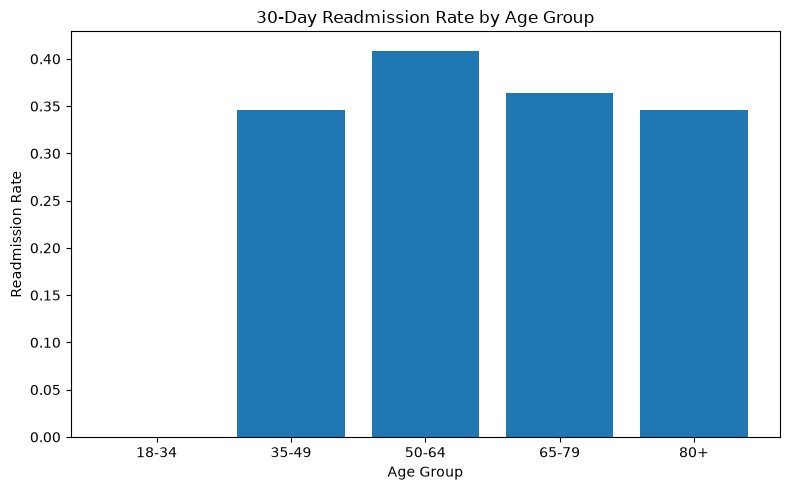

In [17]:
if "age" in df.columns:
    age_bins = [0, 18, 35, 50, 65, 80, 121]
    age_labels = ["0-17", "18-34", "35-49", "50-64", "65-79", "80+"]
    df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

    age_summary = (
        df.groupby("age_group", observed=False)
        .agg(
            encounters=("readmitted_30d", "size"),
            readmission_rate=("readmitted_30d", "mean"),
        )
        .reset_index()
    )
    display(age_summary)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(age_summary["age_group"].astype(str), age_summary["readmission_rate"])
    ax.set_title("30-Day Readmission Rate by Age Group")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Readmission Rate")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "readmission_rate_by_age_group.png", dpi=150)
    plt.show()

## Readmission by payer

In [18]:
if "payer_name" in df.columns:
    payer_summary = (
        df.groupby("payer_name", dropna=False)
        .agg(
            encounters=("readmitted_30d", "size"),
            readmission_rate=("readmitted_30d", "mean"),
            avg_claim_cost=("total_claim_cost", "mean") if "total_claim_cost" in df.columns else ("readmitted_30d", "size"),
        )
        .sort_values(["encounters", "readmission_rate"], ascending=[False, False])
    )
    display(payer_summary)

,encounters,readmission_rate,avg_claim_cost
payer_name,,,
Medicare,492,0.260163,7723.639695
NO_INSURANCE,332,0.460843,9115.516627
Humana,63,0.428571,8622.548571
Dual Eligible,55,0.690909,6936.712182
UnitedHealthcare,49,0.734694,3120.883673
Aetna,41,0.439024,7102.371951
Blue Cross Blue Shield,32,0.125000,7394.855625
Medicaid,30,0.100000,5096.963667
Cigna Health,23,0.086957,8646.072174


## Readmission over time

,admission_year,encounters,readmissions,readmission_rate
0,2011,83,36,0.433735
1,2012,93,28,0.301075
2,2013,134,62,0.462687
3,2014,118,40,0.338983
4,2015,111,30,0.270270
5,2016,124,49,0.395161
6,2017,126,48,0.380952
7,2018,81,18,0.222222
8,2019,134,89,0.664179
9,2020,72,6,0.083333


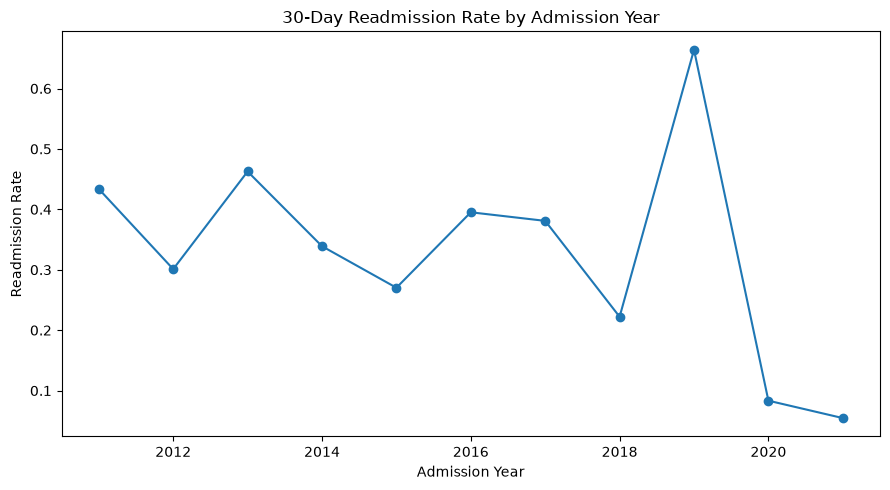

In [19]:
year_summary = (
    df.groupby("admission_year")
    .agg(
        encounters=("readmitted_30d", "size"),
        readmissions=("readmitted_30d", "sum"),
        readmission_rate=("readmitted_30d", "mean"),
    )
    .reset_index()
)

display(year_summary)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(year_summary["admission_year"], year_summary["readmission_rate"], marker="o")
ax.set_title("30-Day Readmission Rate by Admission Year")
ax.set_xlabel("Admission Year")
ax.set_ylabel("Readmission Rate")
fig.tight_layout()
plt.show()

## Leakage check

The target is based on the **next** inpatient encounter. Historical utilization features are constructed from earlier rows only.

Inspect a few patients with multiple encounters to verify sequencing.

In [20]:
multi = df.groupby("patient").size()
example_patients = multi[multi >= 3].head(3).index.tolist()

cols = [
    "patient", "encounter_id", "start", "stop",
    "next_admission", "days_to_next_admission", "readmitted_30d",
    "prior_inpatient_visits", "prior_readmissions",
    "previous_discharge", "days_since_previous_discharge",
]
display(df[df["patient"].isin(example_patients)][cols].sort_values(["patient", "start"]))

,patient,encounter_id,start,stop,next_admission,days_to_next_admission,readmitted_30d,prior_inpatient_visits,prior_readmissions,previous_discharge,days_since_previous_discharge
114,0034fe01-207f-275f-6b4b-821f7b0af044,6d8981d0-df66-8495-d392-b49dba05a982,2012-05-27 11:15:07+00:00,2012-05-28 11:15:07+00:00,2013-08-04 11:15:07+00:00,433.000000,0,0,0.0,NaT,NaN
227,0034fe01-207f-275f-6b4b-821f7b0af044,140689f0-9d90-5600-438e-da0663623f2e,2013-08-04 11:15:07+00:00,2013-08-05 11:15:07+00:00,2014-01-19 11:15:07+00:00,167.000000,0,1,0.0,2012-05-28 11:15:07+00:00,433.000000
315,0034fe01-207f-275f-6b4b-821f7b0af044,543dcbc2-a3cc-a2d1-ac5e-3b722e95e642,2014-01-19 11:15:07+00:00,2014-01-20 11:15:07+00:00,2020-07-01 11:15:07+00:00,2354.000000,0,2,0.0,2013-08-05 11:15:07+00:00,167.000000
1025,0034fe01-207f-275f-6b4b-821f7b0af044,462efc1b-4a39-5dfc-b2c0-84895a08b854,2020-07-01 11:15:07+00:00,2020-07-02 11:15:07+00:00,NaT,NaN,0,3,0.0,2014-01-20 11:15:07+00:00,2354.000000
249,0226f105-2572-1c6f-15f0-1aa0438e40d0,d5c42fa8-f110-b714-d89a-04ec57038a58,2013-10-22 00:16:17+00:00,2013-11-14 00:16:17+00:00,2013-10-31 18:38:09+00:00,-13.234815,0,0,0.0,NaT,NaN
257,0226f105-2572-1c6f-15f0-1aa0438e40d0,af6b3fa6-b6d2-98d6-b182-bcf5c62fdb18,2013-10-31 18:38:09+00:00,2013-11-01 18:38:09+00:00,2013-11-09 21:06:09+00:00,8.102778,1,1,0.0,2013-11-14 00:16:17+00:00,-13.234815
260,0226f105-2572-1c6f-15f0-1aa0438e40d0,907145e6-7e93-9fb6-6114-a67b321881c7,2013-11-09 21:06:09+00:00,2013-11-10 21:06:09+00:00,2013-11-11 03:47:20+00:00,0.278600,1,2,1.0,2013-11-01 18:38:09+00:00,8.102778
262,0226f105-2572-1c6f-15f0-1aa0438e40d0,959a34da-2bf3-cb38-ed0a-558baebc4f79,2013-11-11 03:47:20+00:00,2013-11-12 03:47:20+00:00,2013-11-12 12:15:22+00:00,0.352801,1,3,2.0,2013-11-10 21:06:09+00:00,0.278600
264,0226f105-2572-1c6f-15f0-1aa0438e40d0,e7800bd6-730d-b2f7-dd09-5cc3c1f430ad,2013-11-12 12:15:22+00:00,2013-11-13 12:15:22+00:00,2013-11-13 16:11:30+00:00,0.163981,1,4,3.0,2013-11-12 03:47:20+00:00,0.352801
265,0226f105-2572-1c6f-15f0-1aa0438e40d0,007bc200-faf5-3932-42c8-1113974b2fcf,2013-11-13 16:11:30+00:00,2013-11-14 16:11:30+00:00,2013-11-15 04:17:32+00:00,0.504190,1,5,4.0,2013-11-13 12:15:22+00:00,0.163981


## Findings and Interpretation

After restricting the encounter data to inpatient encounters, **1,135 inpatient encounters** were identified.

To determine whether a subsequent inpatient admission occurred within 30 days, encounters were ordered chronologically within each patient. The next inpatient admission date was compared with the discharge date of the current encounter.

Three encounters occurred too close to the end of the available observation period to provide a complete 30-day follow-up window. These encounters were excluded rather than automatically labeling them as non-readmissions.

### Analytical Dataset

The resulting analytical dataset contains:

| Measure | Result |
|---|---:|
| Eligible inpatient encounters | 1,132 |
| Unique patients | 153 |
| Observed 30-day readmissions | 409 |
| Encounters without a 30-day readmission | 723 |
| Overall 30-day readmission rate | 36.13% |

The positive class is smaller than the negative class but is not extremely rare. Evaluation metrics such as precision, recall, PR-AUC, and ROC-AUC are therefore more informative than accuracy alone.

## Length of Stay

The median inpatient length of stay is approximately **1 day**, and at least 90% of encounters have a length of stay near one day.

However, the maximum observed stay is approximately **343.8 days**, indicating a substantial upper-tail outlier.

This observation does not automatically indicate invalid data, but it should be retained as a data-quality consideration. Tree-based models can accommodate extreme values more naturally than linear models, while the numerical preprocessing pipeline standardizes continuous features for Logistic Regression.

## Patient Age

The mean age at inpatient admission is approximately **71 years**, indicating that the inpatient population represented in the data is relatively old.

Observed readmission rates differ across age groups, but these differences should not be interpreted as causal relationships. Some age categories contain substantially fewer observations than others, and the dataset is synthetic.

Age-group results are therefore treated as descriptive patterns rather than evidence that age independently causes readmission.

## Payer Patterns

Medicare represents the largest payer group within the inpatient modeling population, followed by encounters categorized as having no insurance.

Observed readmission rates vary across payer categories. Several smaller payer categories show relatively high or low readmission rates, but small sample sizes make those estimates less stable.

Payer-level differences should therefore be treated as descriptive findings rather than evidence that insurance type independently determines readmission risk.

## Time-Based Patterns

Readmission rates vary across calendar years. This variation supports the use of a **chronological train/test split** rather than a random split because the model should be evaluated on later encounters that were not used during training.

The later years of the dataset also contain fewer inpatient encounters than several earlier years. In particular, 2022 contains only a small portion of the year and should not be interpreted as a complete annual period.

## Exploratory Analysis Conclusion

The exploratory analysis supports proceeding with predictive modeling while retaining several considerations:

- the dataset contains repeated encounters for the same patients;
- the observed readmission rate changes over time;
- some payer and demographic groups have relatively small sample sizes;
- length of stay contains an extreme upper-tail value;
- prior patient utilization is likely to provide useful predictive information;
- demographic and payer differences should remain descriptive rather than causal; and
- incomplete follow-up at the end of the observation period must be handled explicitly.

These observations guide the feature-engineering and validation decisions in the next notebook.
